In [2]:
import plotnine as p9
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv("german_credit_clean.csv")

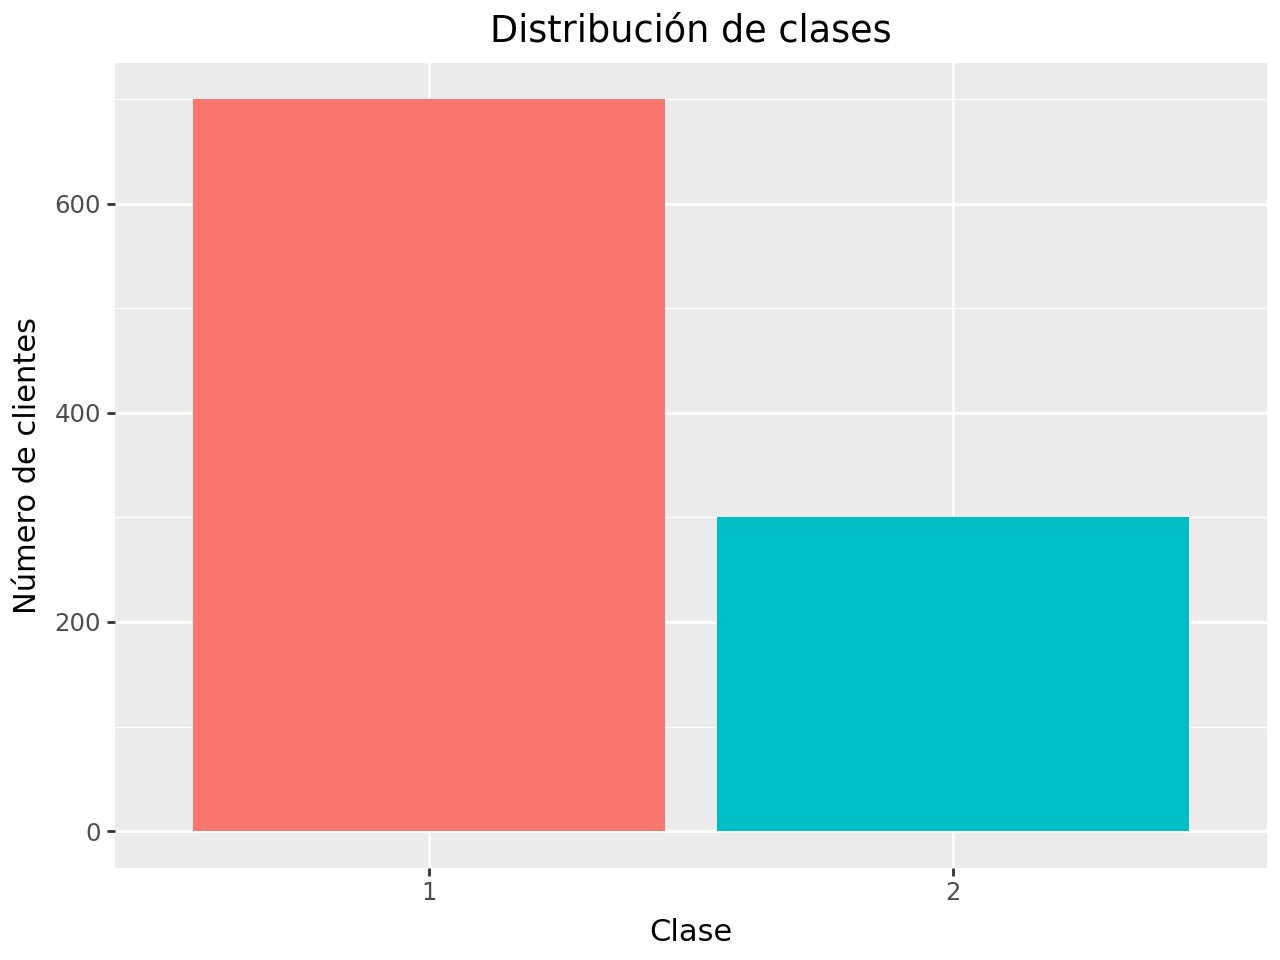

In [ ]:
#Gráfico 1 (distribución de clases): muestra el número de clientes en cada categoría de 
#riesgo (buen/mal cliente), permitiendo ver si el dataset está equilibrado o desbalanceado.

df["class"] = df["class"].astype(str)

(
    p9.ggplot(df) +
    p9.geom_bar(
        p9.aes(x='class', fill='class'),
        show_legend=False
    ) +
    p9.scale_x_discrete(limits=["1", "2"]) +
    p9.labs(
        title="Distribución de clases",
        x="Clase",
        y="Número de clientes"
    )
)

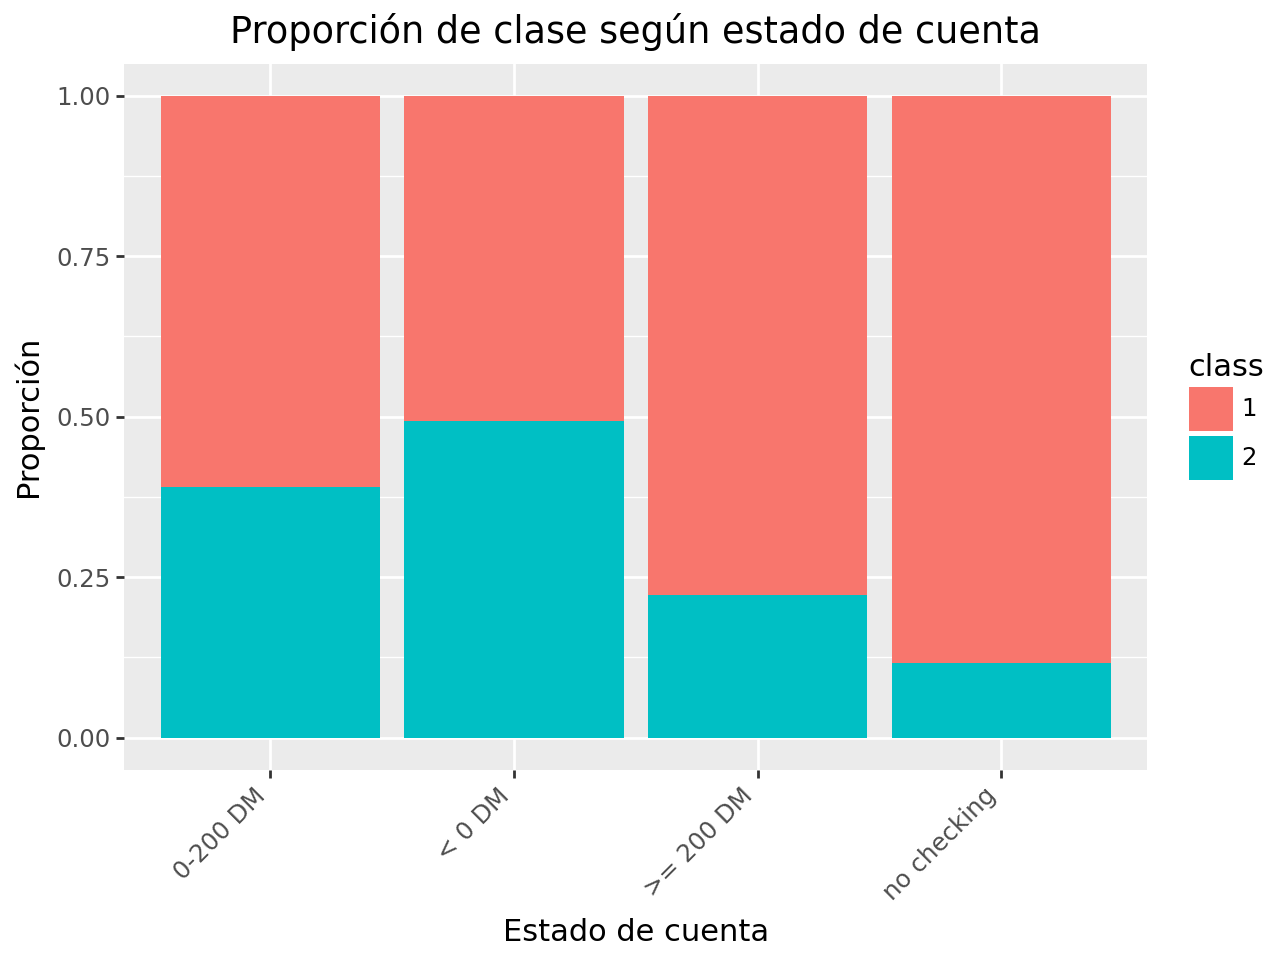

In [12]:
#Gráfico 2 (estado de cuenta vs clase, proporciones): muestra la proporción de buenos y malos clientes 
#dentro de cada tipo de cuenta bancaria, permitiendo identificar qué niveles de saldo están asociados 
#a mayor riesgo crediticio.

(
    p9.ggplot(df) +
    p9.geom_bar(
        p9.aes(x='checking_status', fill='class'),
        position='fill'
    ) +
    p9.labs(
        title="Proporción de clase según estado de cuenta",
        x="Estado de cuenta",
        y="Proporción"
    ) +
    p9.theme(axis_text_x=p9.element_text(rotation=45, hjust=1))
)

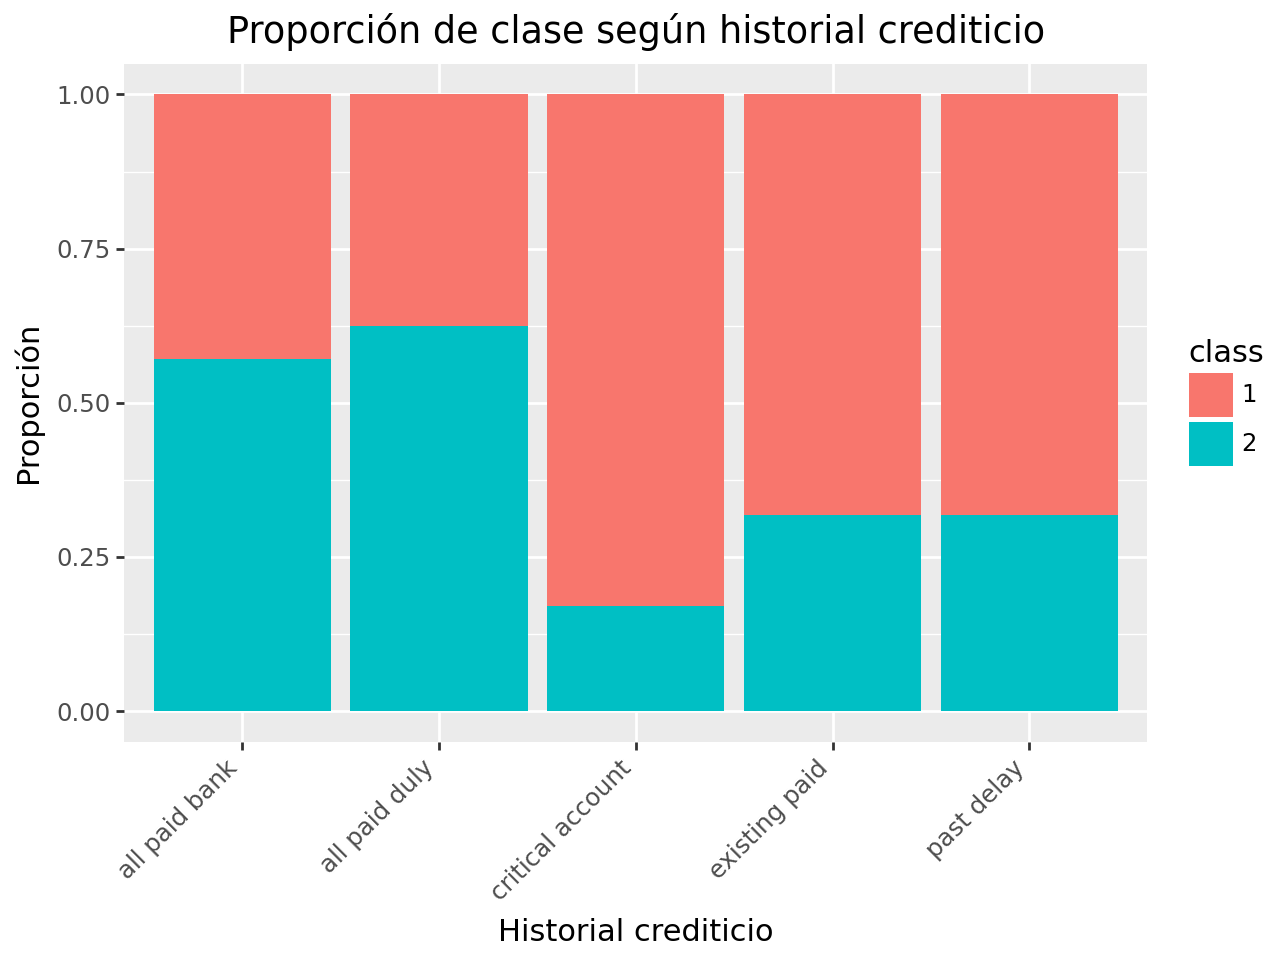

In [ ]:
#Gráfico 3 (historial crediticio vs clase, proporciones): muestra cómo varía la proporción de buenos 
#y malos clientes según su historial de crédito previo. Permite identificar que un historial más
#negativo o con retrasos se asocia a mayor riesgo de impago.

(
    p9.ggplot(df) +
    p9.geom_bar(
        p9.aes(x='credit_history', fill='class'),
        position='fill'
    ) +
    p9.labs(
        title="Proporción de clase según historial crediticio",
        x="Historial crediticio",
        y="Proporción"
    ) +
    p9.theme(axis_text_x=p9.element_text(rotation=45, hjust=1))
)

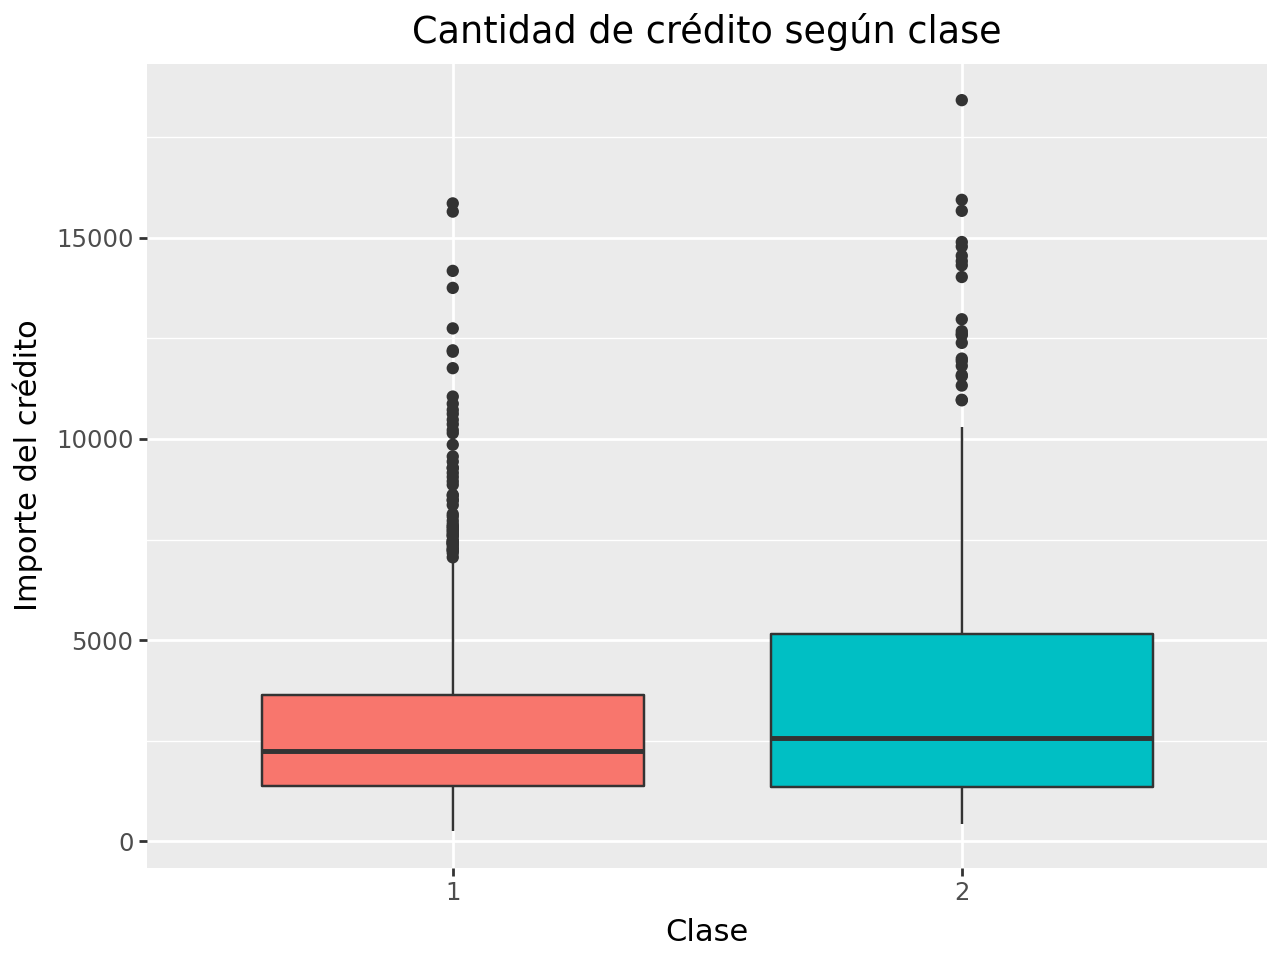

In [ ]:
#Gráfico 4 (cantidad de crédito según clase): muestra la distribución del importe del crédito para 
#clientes buenos y malos, permitiendo comparar medianas, dispersión y posibles outliers entre ambas 
#clases. Ayuda a identificar si los clientes de mayor riesgo tienden a solicitar préstamos de mayor 
#cuantía.

(
    p9.ggplot(df) +
    p9.geom_boxplot(
        p9.aes(x='class', y='credit_amount', fill='class'),
        show_legend=False
    ) +
    p9.labs(
        title="Cantidad de crédito según clase",
        x="Clase",
        y="Importe del crédito"
    ) +
    p9.theme(axis_text_x=p9.element_text(rotation=0))
)

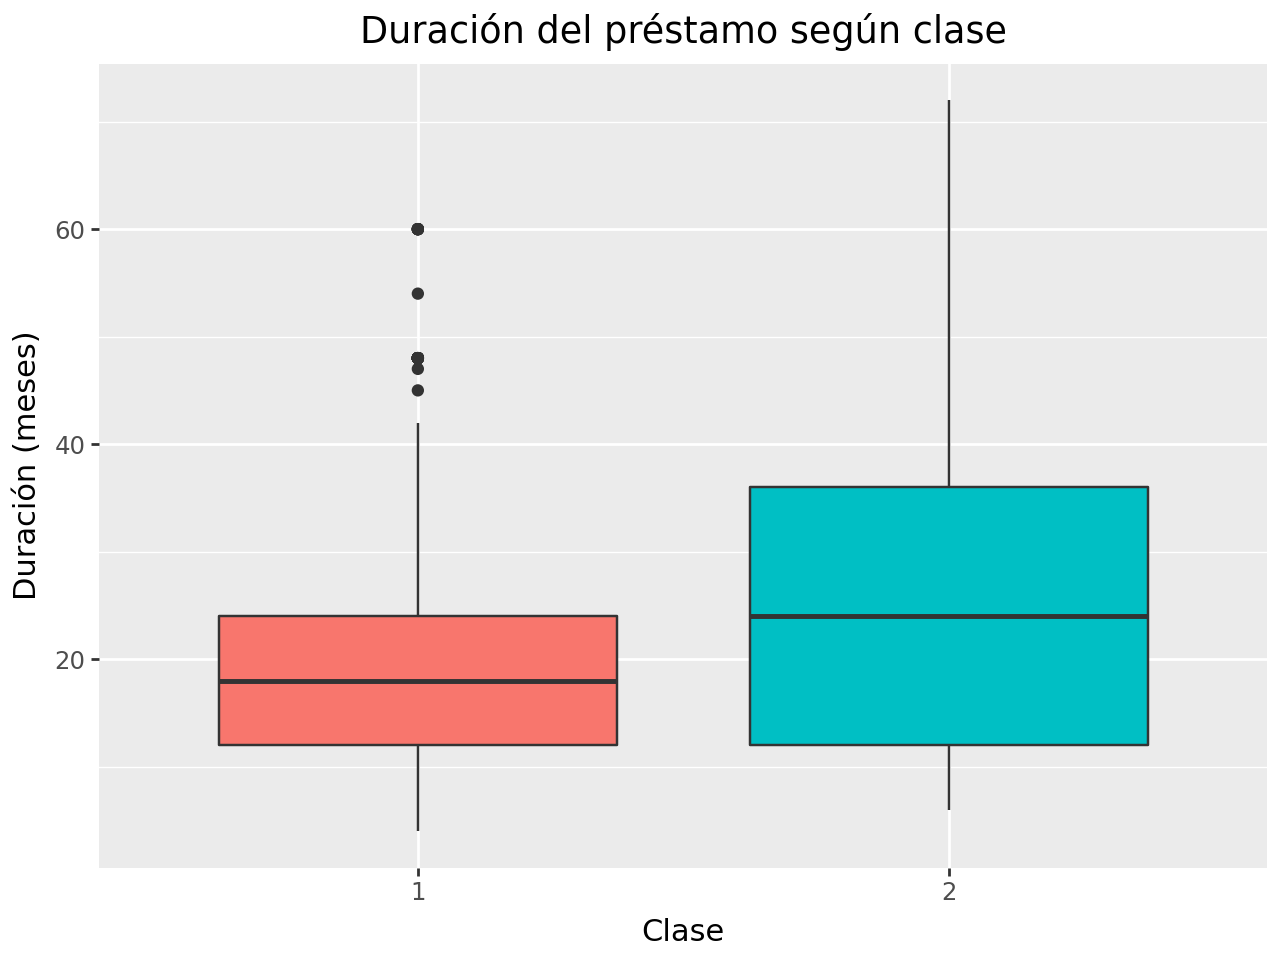

In [ ]:
#Gráfico 5 (duración del préstamo según clase): muestra la distribución de la duración de los 
#préstamos para clientes buenos y malos, permitiendo comparar diferencias en mediana, variabilidad 
#y outliers entre ambas clases. Ayuda a evaluar si los préstamos de mayor duración están asociados 
#a un mayor riesgo de impago.

(
    p9.ggplot(df) +
    p9.geom_boxplot(
        p9.aes(x='class', y='duration_months', fill='class'),
        show_legend=False
    ) +
    p9.labs(
        title="Duración del préstamo según clase",
        x="Clase",
        y="Duración (meses)"
    ) +
    p9.theme(axis_text_x=p9.element_text(rotation=0))
)

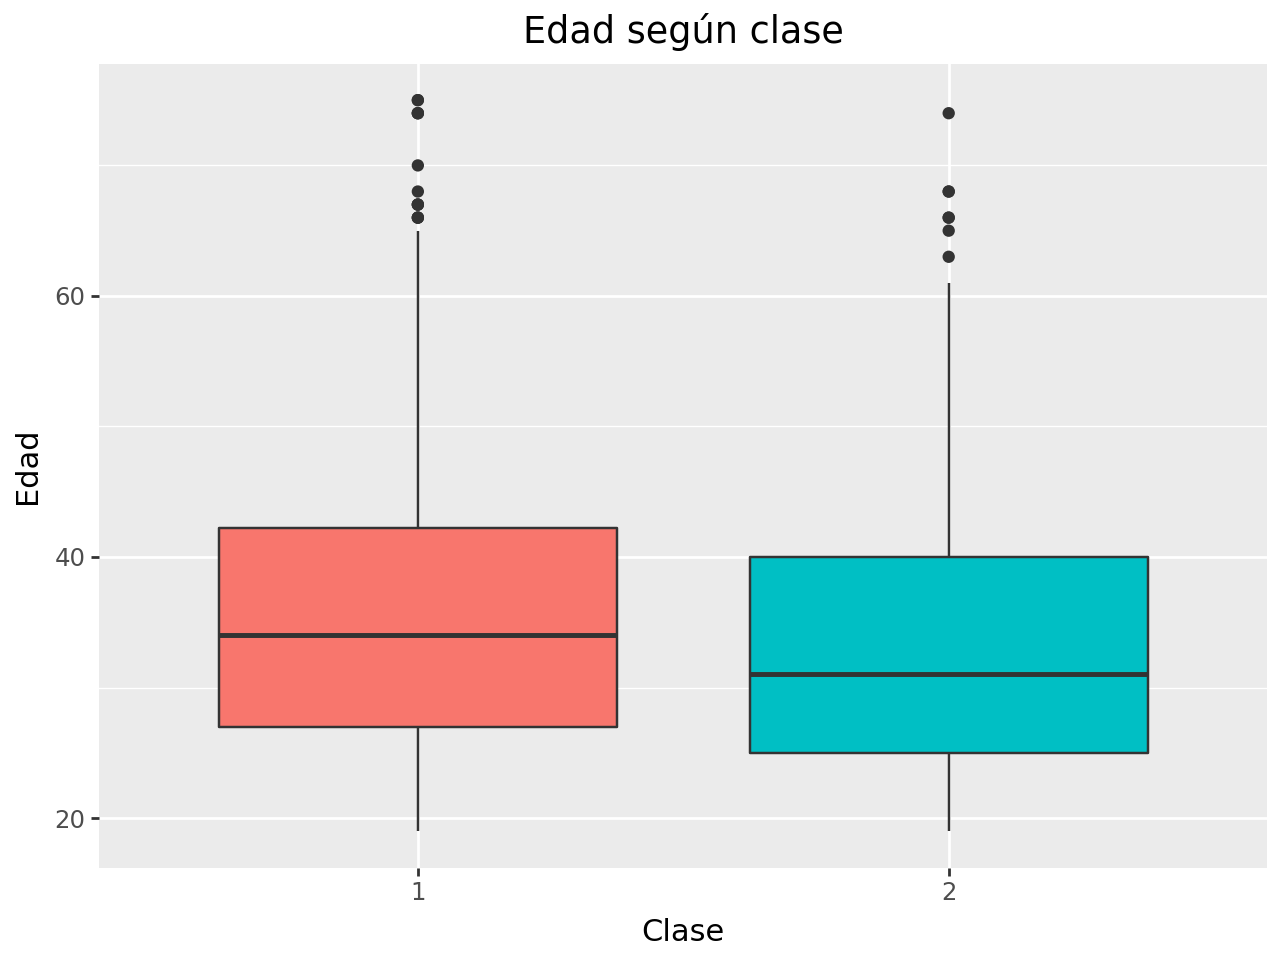

In [23]:
#Gráfico 6 (edad según clase): muestra la distribución de la edad de los clientes en función de 
#su clase (buenos o malos), permitiendo comparar diferencias en la mediana, dispersión y posibles 
#valores extremos entre ambos grupos. Ayuda a evaluar si la edad tiene relación con la probabilidad
#de impago.

(
    p9.ggplot(df) +
    p9.geom_boxplot(
        p9.aes(x='class', y='age', fill='class'),
        show_legend=False
    ) +
    p9.labs(
        title="Edad según clase",
        x="Clase",
        y="Edad"
    ) +
    p9.theme(axis_text_x=p9.element_text(rotation=0))
)

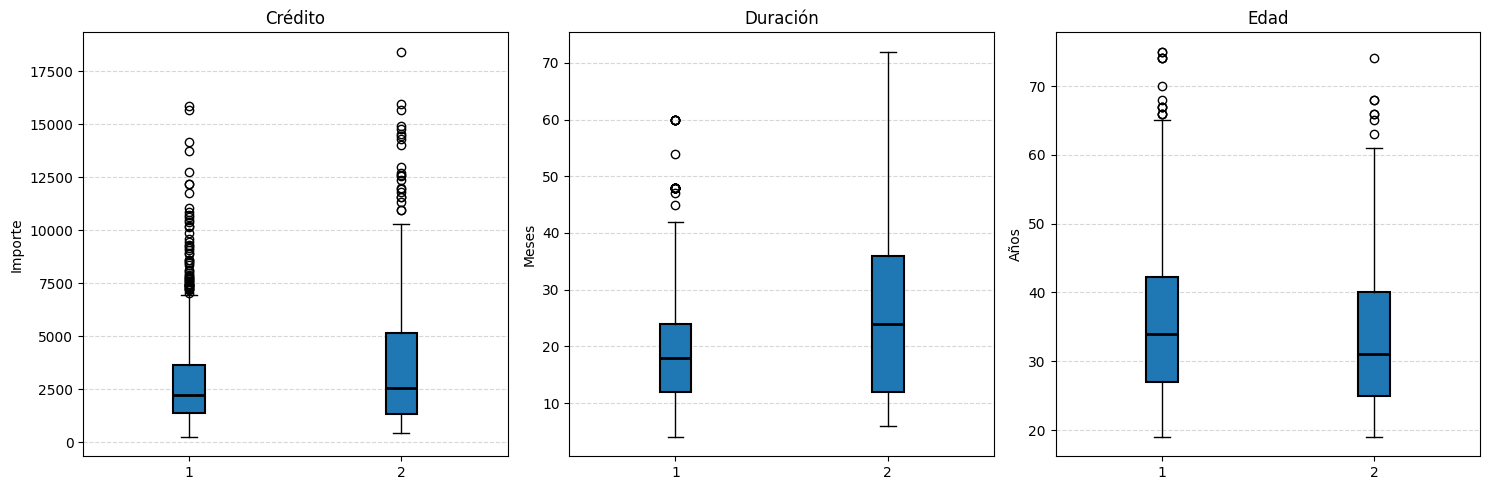

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

boxprops = dict(linewidth=1.5)
medianprops = dict(linewidth=2, color='black')

# --- Crédito ---
ax[0].boxplot([
    df[df["class"] == "1"]["credit_amount"],
    df[df["class"] == "2"]["credit_amount"]
], patch_artist=True, boxprops=boxprops, medianprops=medianprops)

ax[0].set_title("Crédito")
ax[0].set_xticklabels(["1", "2"])
ax[0].set_ylabel("Importe")
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Duración ---
ax[1].boxplot([
    df[df["class"] == "1"]["duration_months"],
    df[df["class"] == "2"]["duration_months"]
], patch_artist=True, boxprops=boxprops, medianprops=medianprops)

ax[1].set_title("Duración")
ax[1].set_xticklabels(["1", "2"])
ax[1].set_ylabel("Meses")
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

# --- Edad ---
ax[2].boxplot([
    df[df["class"] == "1"]["age"],
    df[df["class"] == "2"]["age"]
], patch_artist=True, boxprops=boxprops, medianprops=medianprops)

ax[2].set_title("Edad")
ax[2].set_xticklabels(["1", "2"])
ax[2].set_ylabel("Años")
ax[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

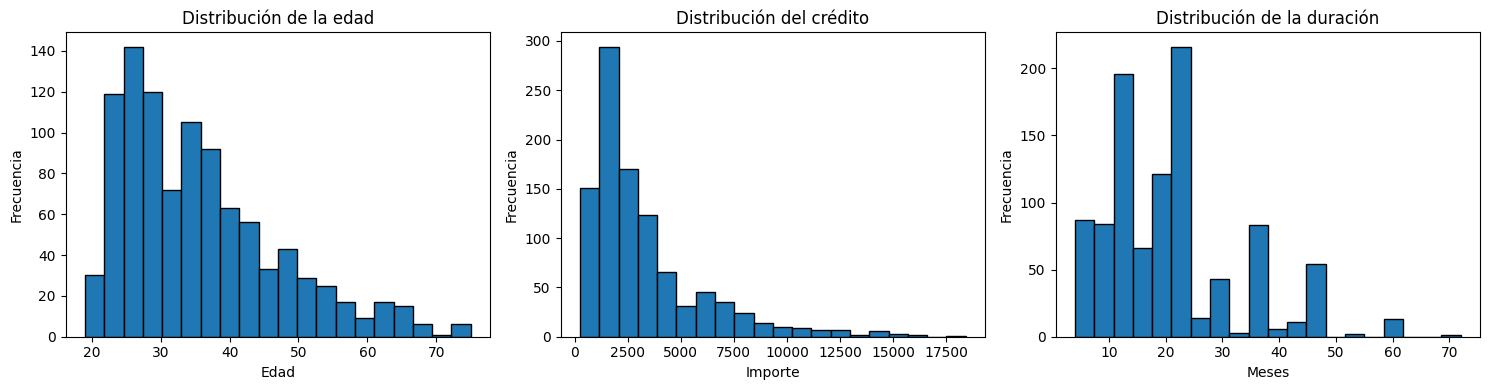

In [ ]:
#Gráfico 7 (distribución de variables numéricas): muestra la forma de distribución de la edad, el 
#importe del crédito y la duración del préstamo, permitiendo identificar sesgos, concentración de 
#valores y posibles outliers en cada variable. Esto ayuda a comprender la estructura de los datos 
#antes de aplicar modelos de clasificación.

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Edad
ax[0].hist(df["age"], bins=20, edgecolor="black")
ax[0].set_title("Distribución de la edad")
ax[0].set_xlabel("Edad")
ax[0].set_ylabel("Frecuencia")

# Importe del crédito
ax[1].hist(df["credit_amount"], bins=20, edgecolor="black")
ax[1].set_title("Distribución del crédito")
ax[1].set_xlabel("Importe")
ax[1].set_ylabel("Frecuencia")

# Duración
ax[2].hist(df["duration_months"], bins=20, edgecolor="black")
ax[2].set_title("Distribución de la duración")
ax[2].set_xlabel("Meses")
ax[2].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

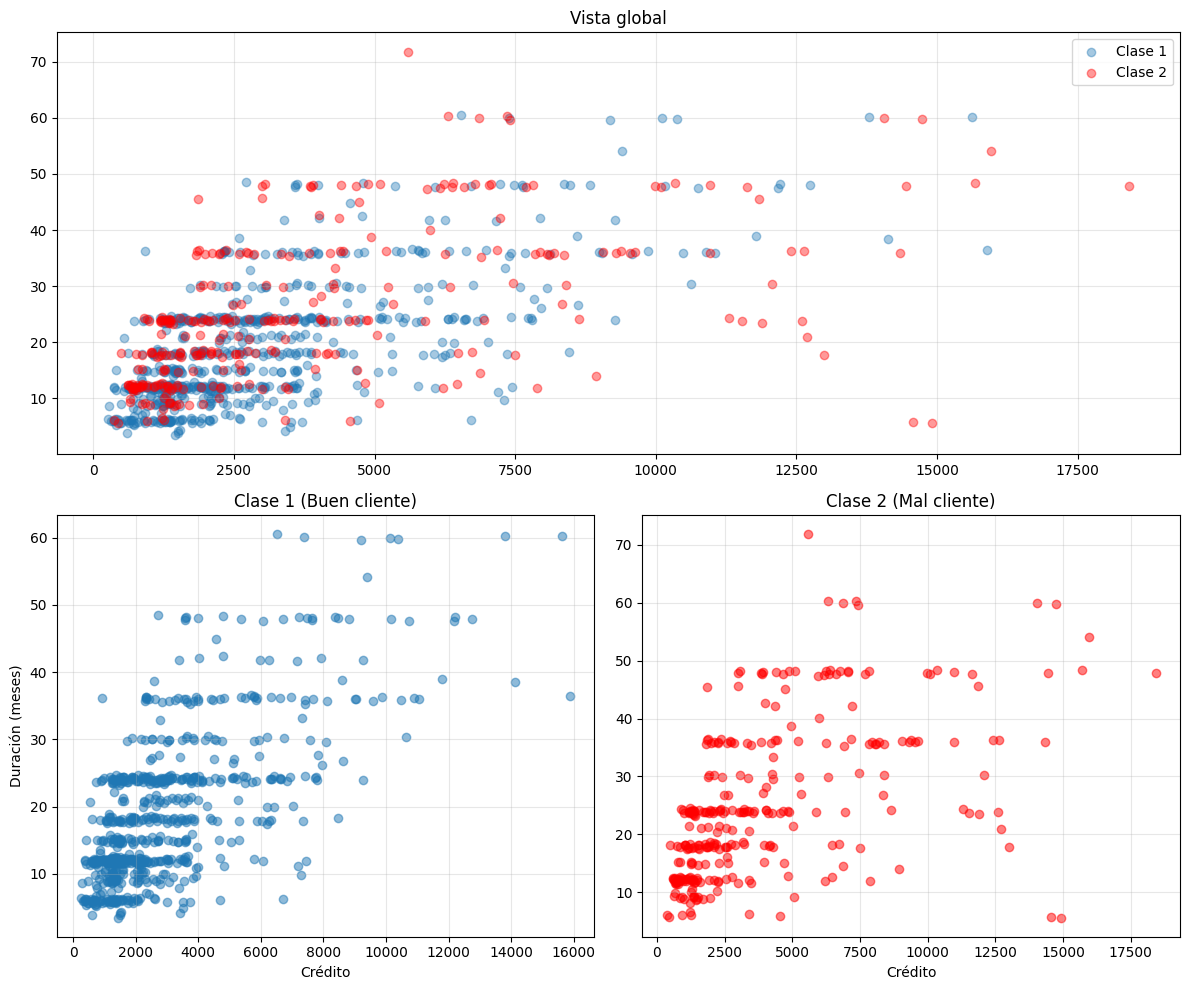

In [ ]:
#Gráfico 8 (relación entre crédito y duración del préstamo según clase): muestra la relación entre 
#el importe del crédito y la duración del préstamo, separando visualmente a los clientes en función 
#de su clase (buenos y malos). Permite analizar si existe una asociación entre ambas variables y 
#si los patrones difieren entre grupos, observando la concentración de puntos, la dispersión y 
#posibles diferencias estructurales entre clases.

fig = plt.figure(figsize=(12, 10))

gs = fig.add_gridspec(2, 2)

noise = 0.3

df1 = df[df["class"] == "1"]
df2 = df[df["class"] == "2"]

x1 = df1["credit_amount"] + np.random.normal(0, df1["credit_amount"].std() * 0.01, len(df1))
y1 = df1["duration_months"] + np.random.normal(0, noise, len(df1))

x2 = df2["credit_amount"] + np.random.normal(0, df2["credit_amount"].std() * 0.01, len(df2))
y2 = df2["duration_months"] + np.random.normal(0, noise, len(df2))


ax0 = fig.add_subplot(gs[0, :])

ax0.scatter(x1, y1, alpha=0.4, label="Clase 1")
ax0.scatter(x2, y2, alpha=0.4, color="red", label="Clase 2")
ax0.set_title("Vista global")
ax0.legend()
ax0.grid(alpha=0.3)


ax1 = fig.add_subplot(gs[1, 0])
ax1.scatter(x1, y1, alpha=0.5)
ax1.set_title("Clase 1 (Buen cliente)")
ax1.set_xlabel("Crédito")
ax1.set_ylabel("Duración (meses)")
ax1.grid(alpha=0.3)


ax2 = fig.add_subplot(gs[1, 1])
ax2.scatter(x2, y2, alpha=0.5, color="red")
ax2.set_title("Clase 2 (Mal cliente)")
ax2.set_xlabel("Crédito")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

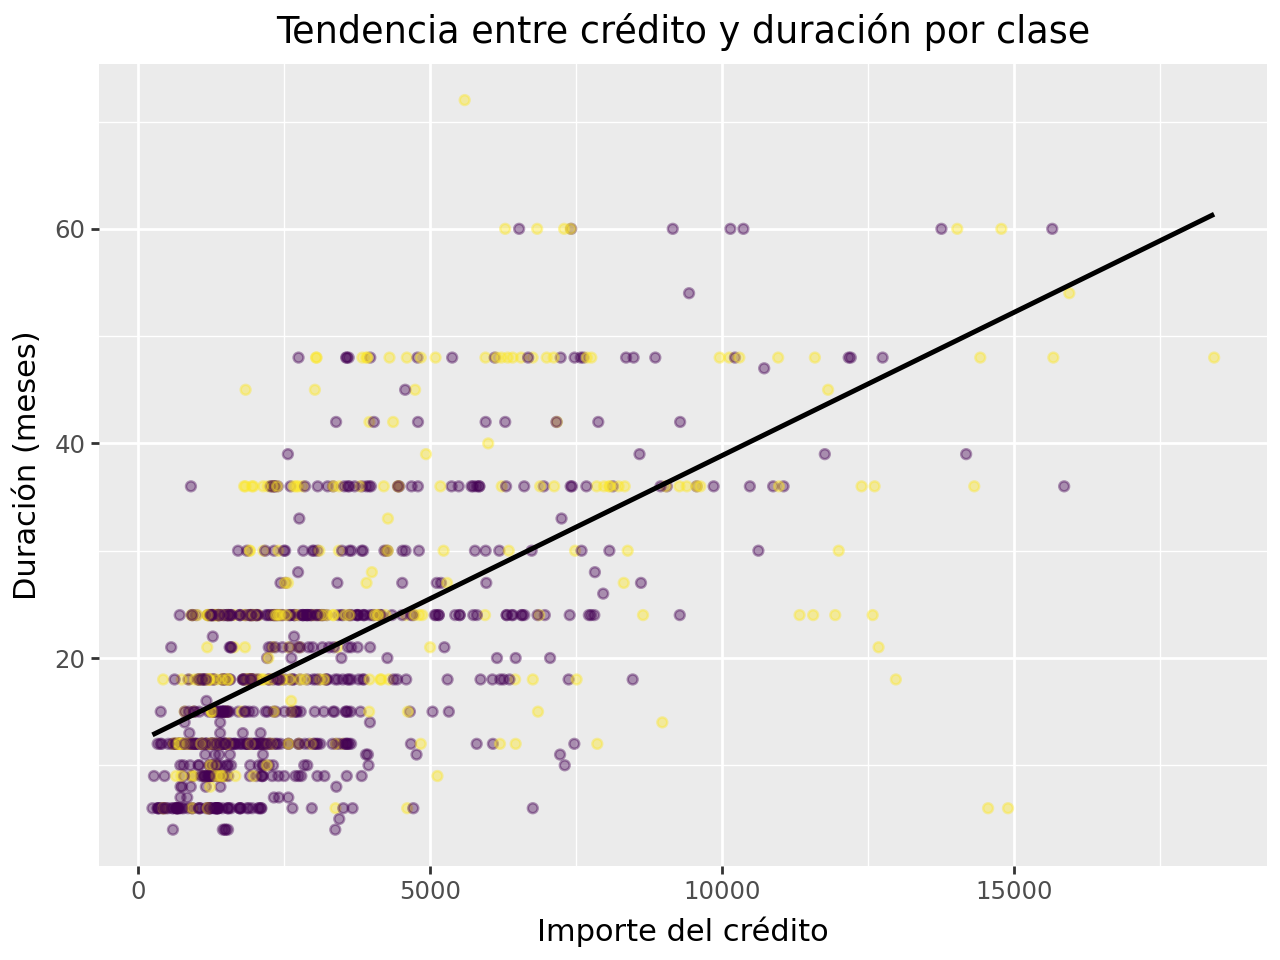

In [ ]:
#Gráfico 9 (tendencia entre variables numéricas): muestra la relación entre el importe del crédito 
#y la duración del préstamo mediante una nube de puntos junto con líneas de regresión lineal 
#diferenciadas por clase. Permite analizar la tendencia general entre ambas variables y comprobar 
#si dicha relación cambia entre buenos y malos clientes, aportando una visión estadística del 
#comportamiento conjunto de las variables.

#Basicamente lo mismo que la anterior pero con la regresion

(
    p9.ggplot(df) +
    p9.geom_point(
        p9.aes(x='credit_amount', y='duration_months', color='class'),
        alpha=0.4
    ) +
    p9.geom_smooth(
        p9.aes(x='credit_amount', y='duration_months', color='class'),
        method='lm',
        se=False
    ) +
    p9.labs(
        title="Tendencia entre crédito y duración por clase",
        x="Importe del crédito",
        y="Duración (meses)"
    ) +
    p9.theme(legend_position="none")
)

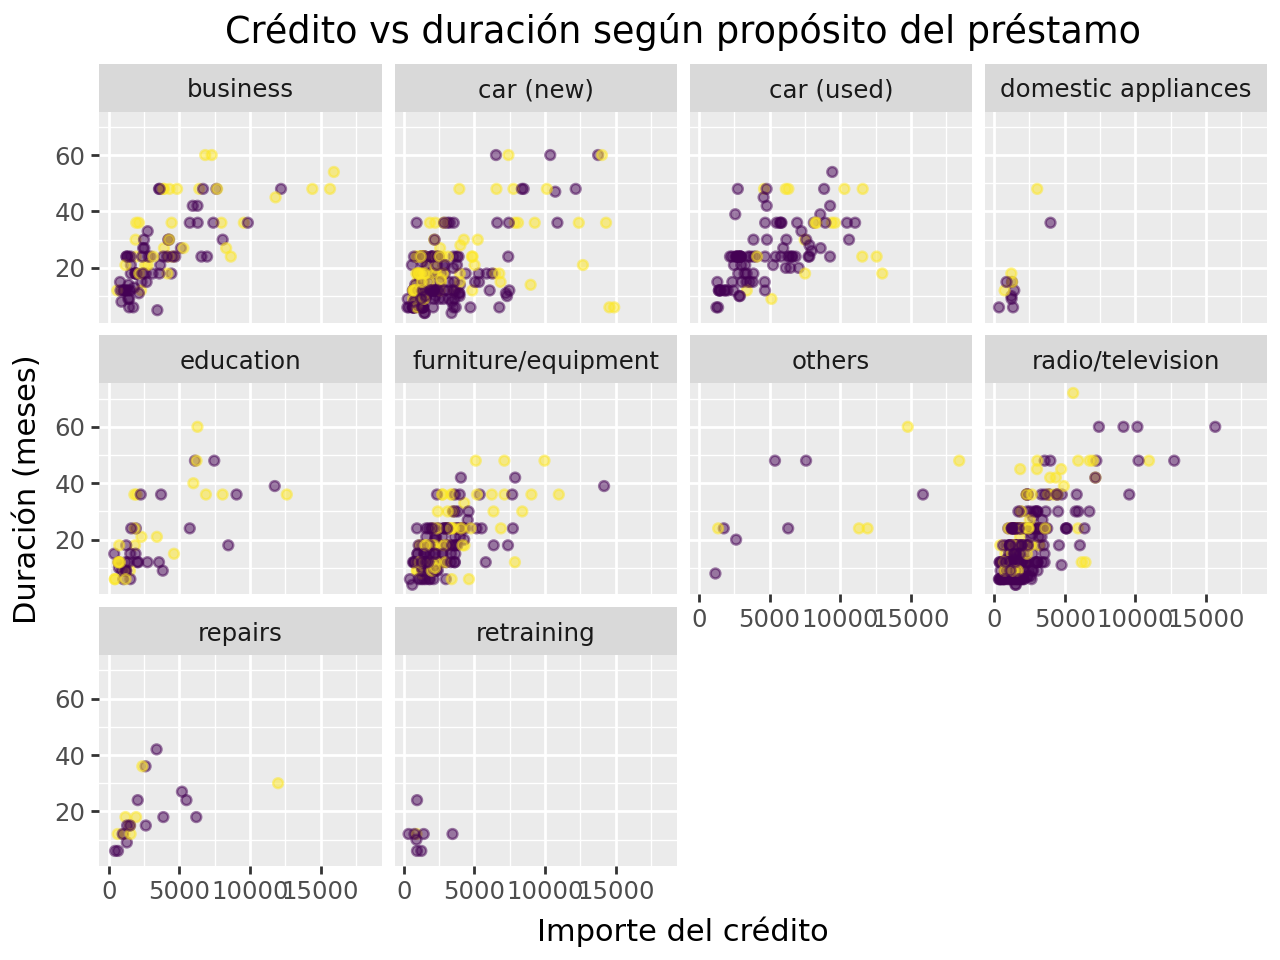

In [ ]:
#Gráfica 10.1 (purpose): Muestra la relación entre el importe del crédito y la duración del préstamo 
#segmentada según el propósito del crédito. Permite identificar si ciertos tipos de gasto 
#(como coche, educación o negocio) presentan patrones distintos de riesgo o condiciones de 
#financiación.

(
    p9.ggplot(df) +
    p9.geom_point(
        p9.aes(x='credit_amount', y='duration_months', color='class'),
        alpha=0.5
    ) +
    p9.facet_wrap('~purpose') +
    p9.labs(
        title="Crédito vs duración según propósito del préstamo",
        x="Importe del crédito",
        y="Duración (meses)"
    ) +
    p9.theme(legend_position="none")
)

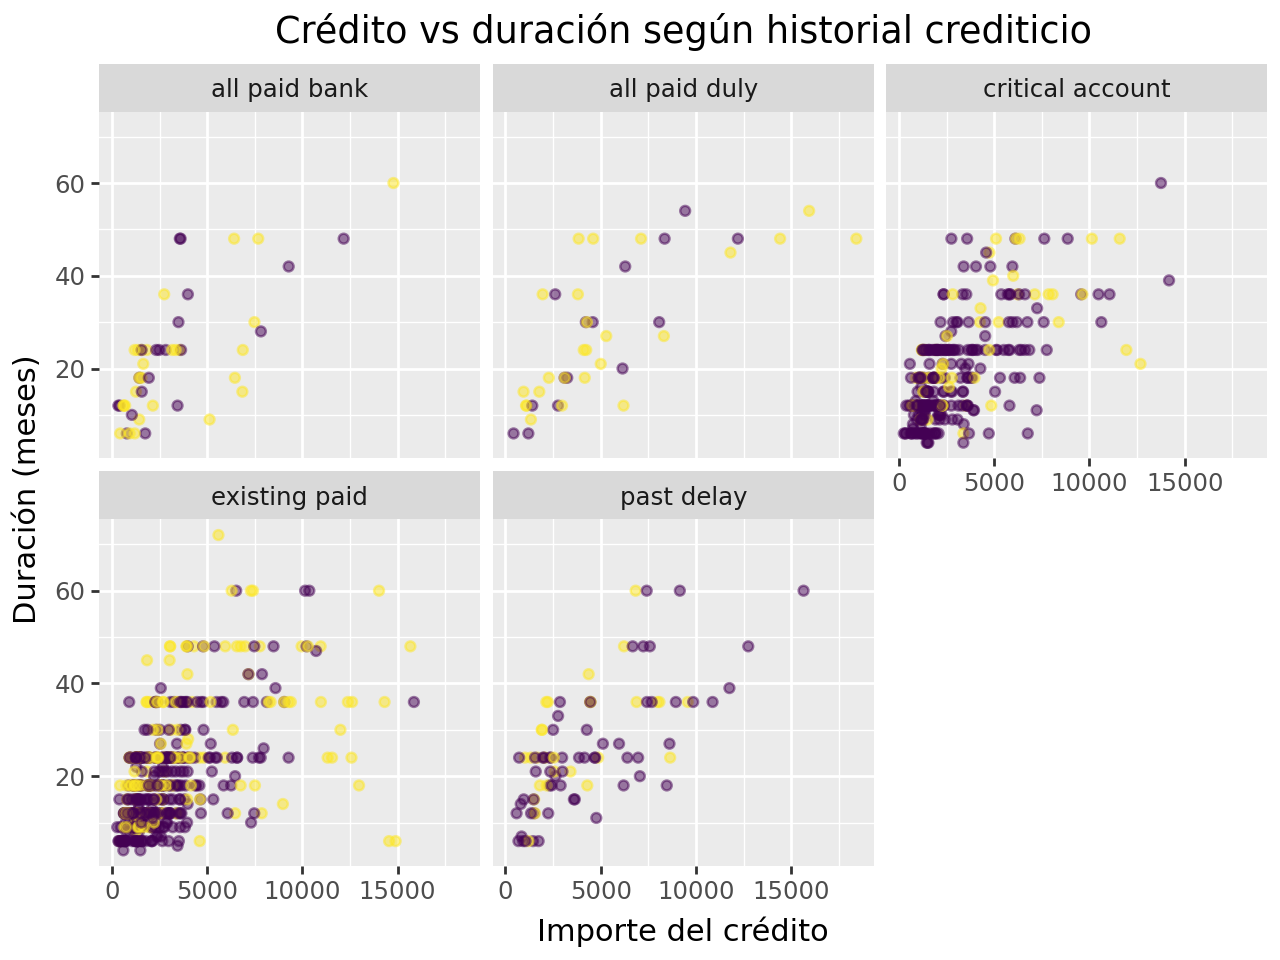

In [ ]:
#Gráfica 10.2 (credit_history): Muestra la relación entre el importe del crédito y la duración del 
#préstamo según el historial crediticio del cliente. Permite analizar cómo el comportamiento 
#financiero previo influye en el tipo de préstamo concedido y en su duración.

(
    p9.ggplot(df) +
    p9.geom_point(
        p9.aes(x='credit_amount', y='duration_months', color='class'),
        alpha=0.5
    ) +
    p9.facet_wrap('~credit_history') +
    p9.labs(
        title="Crédito vs duración según historial crediticio",
        x="Importe del crédito",
        y="Duración (meses)"
    ) +
    p9.theme(legend_position="none")
)

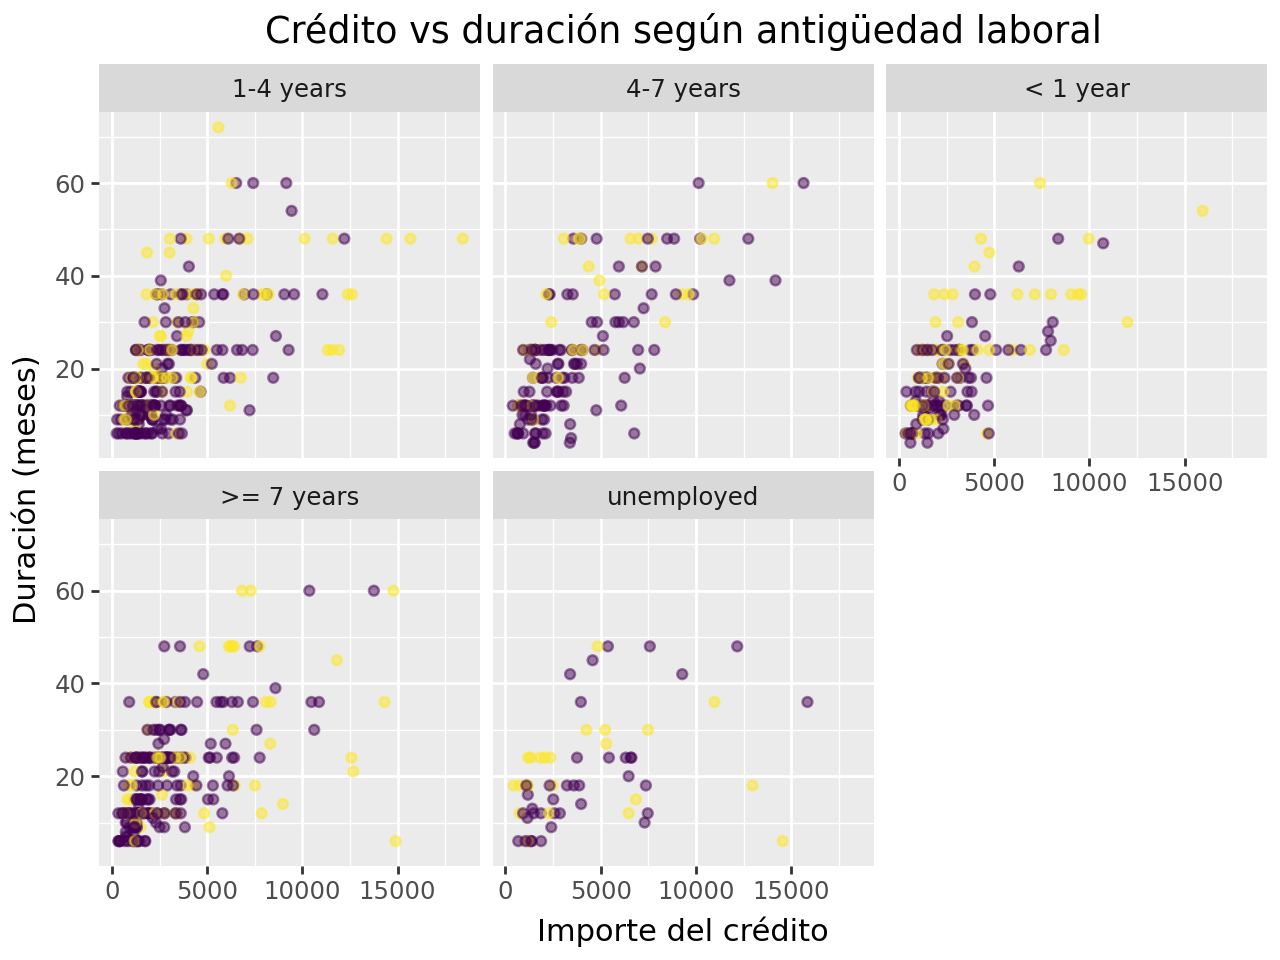

In [ ]:
#Gráfica 10.3 (employment_since): Muestra la relación entre el importe del crédito y la duración 
#del préstamo según la antigüedad laboral del cliente. Permite evaluar si una mayor estabilidad 
#laboral se asocia con préstamos de mayor importe o duración.

(
    p9.ggplot(df) +
    p9.geom_point(
        p9.aes(x='credit_amount', y='duration_months', color='class'),
        alpha=0.5
    ) +
    p9.facet_wrap('~employment_since') +
    p9.labs(
        title="Crédito vs duración según antigüedad laboral",
        x="Importe del crédito",
        y="Duración (meses)"
    ) +
    p9.theme(legend_position="none")
)

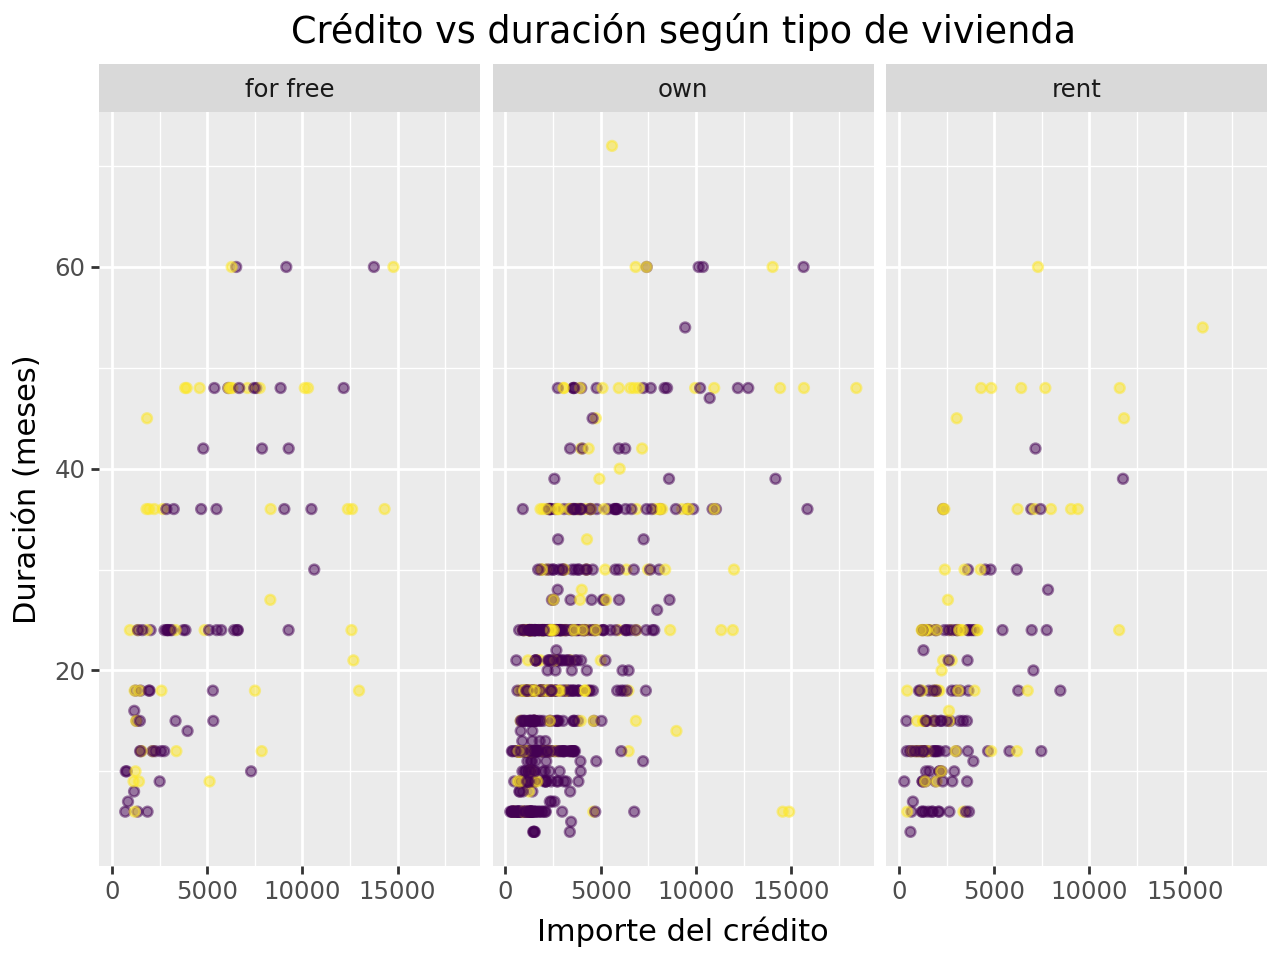

In [ ]:
#Gráfica 10.4 (housing_type): Muestra la relación entre el importe del crédito y la duración del 
#préstamo según el tipo de vivienda del cliente. Permite observar si la situación habitacional 
#influye en el acceso a créditos más grandes o más largos.

(
    p9.ggplot(df) +
    p9.geom_point(
        p9.aes(x='credit_amount', y='duration_months', color='class'),
        alpha=0.5
    ) +
    p9.facet_wrap('~housing_type') +
    p9.labs(
        title="Crédito vs duración según tipo de vivienda",
        x="Importe del crédito",
        y="Duración (meses)"
    ) +
    p9.theme(legend_position="none")
)

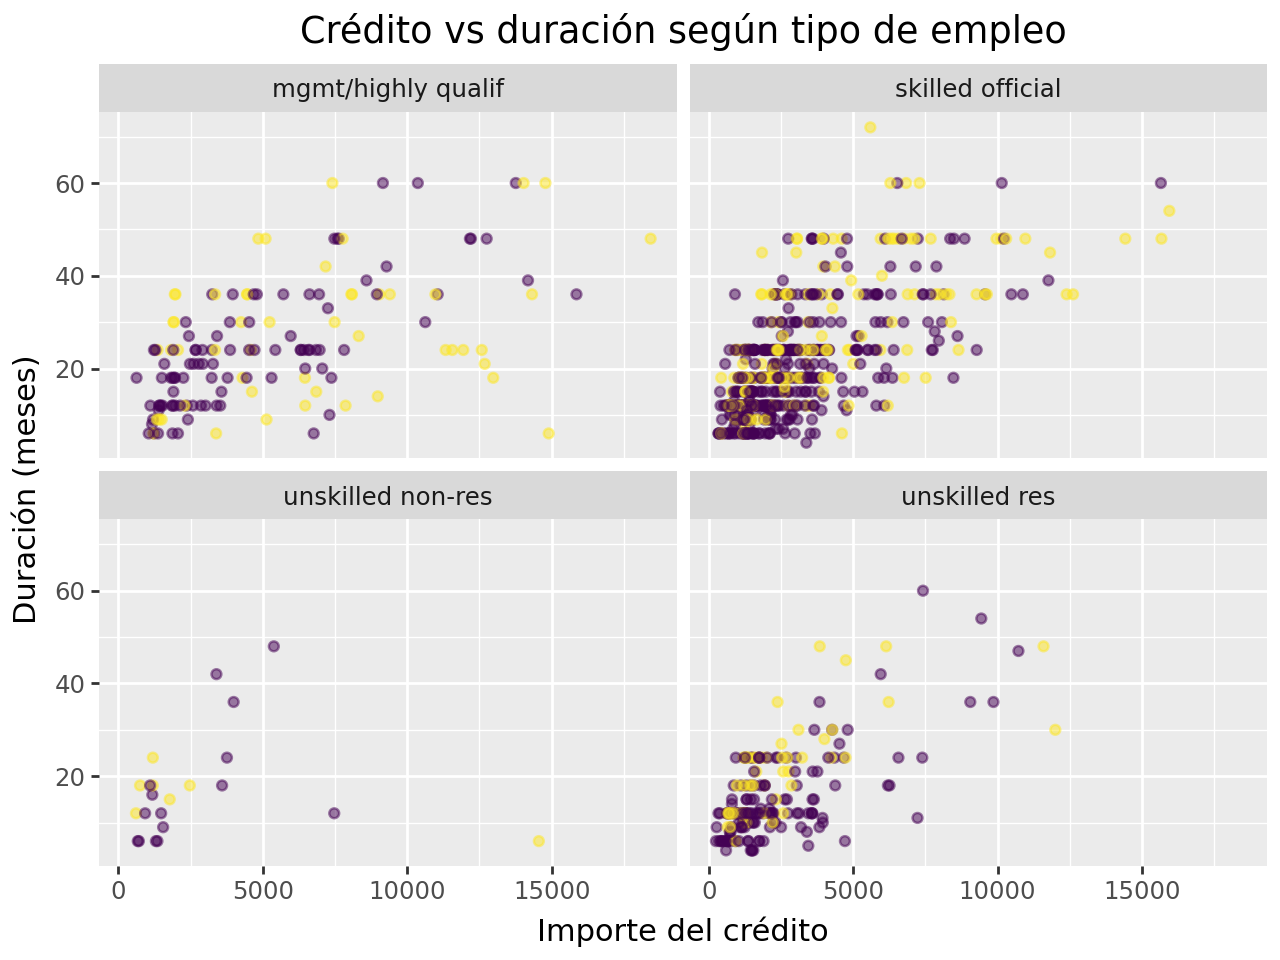

In [ ]:
#Gráfica 10.5 (job_type): Muestra la relación entre el importe del crédito y la duración del 
#préstamo según el tipo de empleo del cliente. Permite analizar diferencias socioeconómicas en 
#la concesión y características de los préstamos.

(
    p9.ggplot(df) +
    p9.geom_point(
        p9.aes(x='credit_amount', y='duration_months', color='class'),
        alpha=0.5
    ) +
    p9.facet_wrap('~job_type') +
    p9.labs(
        title="Crédito vs duración según tipo de empleo",
        x="Importe del crédito",
        y="Duración (meses)"
    ) +
    p9.theme(legend_position="none")
)

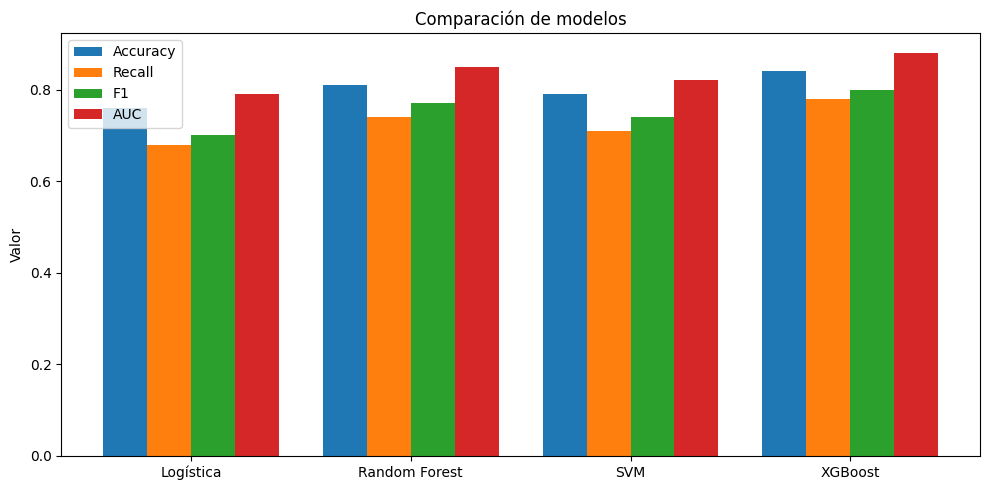

In [ ]:
#Grafico 11 (comparacion de modelos): con metricas inventadas, simplemente para tener la estructura 
#para futuro.
#De aquí en adelante todo son con resultados inventados

modelos = ["Logística", "Random Forest", "SVM", "XGBoost"]

accuracy = [0.76, 0.81, 0.79, 0.84]
recall = [0.68, 0.74, 0.71, 0.78]
f1 = [0.70, 0.77, 0.74, 0.80]
auc = [0.79, 0.85, 0.82, 0.88]

x = np.arange(len(modelos))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - 1.5*width, accuracy, width, label="Accuracy")
ax.bar(x - 0.5*width, recall, width, label="Recall")
ax.bar(x + 0.5*width, f1, width, label="F1")
ax.bar(x + 1.5*width, auc, width, label="AUC")

ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.set_ylabel("Valor")
ax.set_title("Comparación de modelos")
ax.legend()

plt.tight_layout()
plt.show()

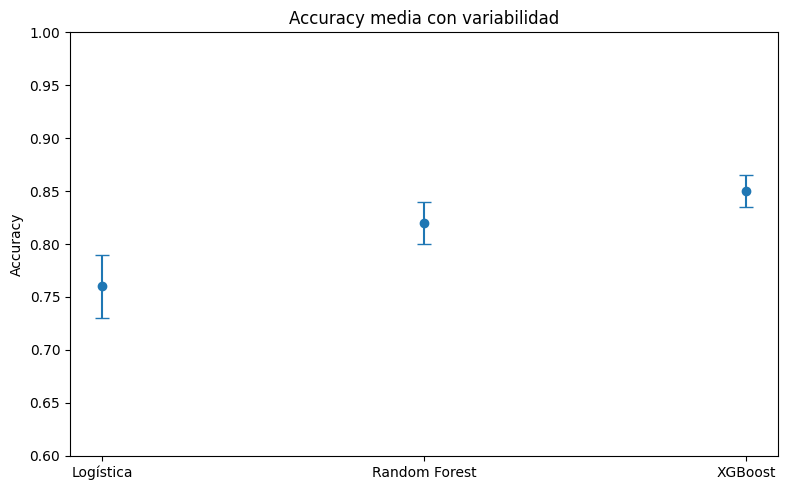

In [ ]:
#Grafico 13 (comparacion de metricas con incertidumbre): basicamente lo mismo que antes pero esta 
#vez incluyendo barras de error para representar la variabilidad de los modelos en validacion cruzada.

modelos = ["Logística", "Random Forest", "XGBoost"]

media = [0.76, 0.82, 0.85]

std = [0.03, 0.02, 0.015]

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    modelos,
    media,
    yerr=std,
    fmt='o',
    capsize=5
)

ax.set_title("Accuracy media con variabilidad")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.6, 1)

plt.tight_layout()
plt.show()

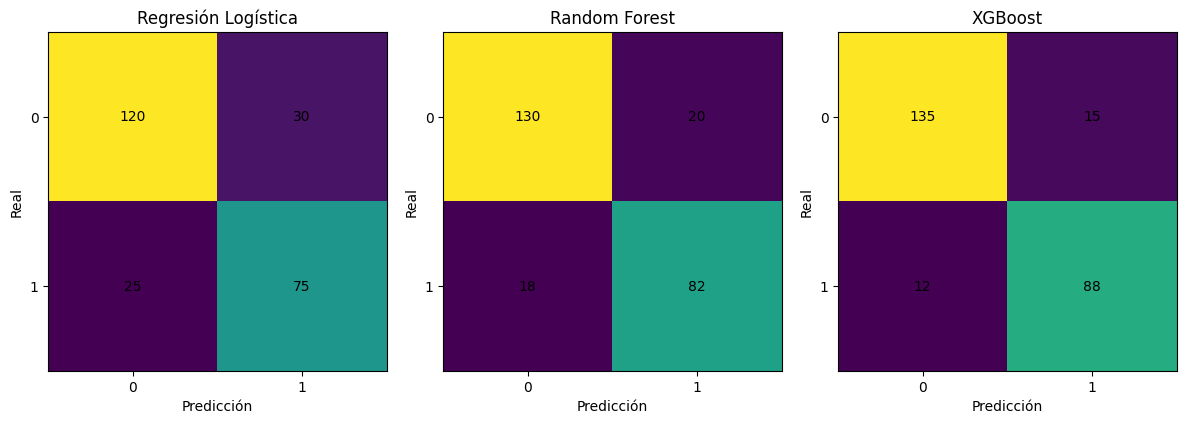

In [ ]:
#Grafica 13 (matriz de confusion): matriz de confusion para distintos modelos

cm_logistica = np.array([[120, 30],
                         [25, 75]])

cm_rf = np.array([[130, 20],
                  [18, 82]])

cm_xgb = np.array([[135, 15],
                   [12, 88]])

matrices = [cm_logistica, cm_rf, cm_xgb]
titulos = ["Regresión Logística", "Random Forest", "XGBoost"]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

for i in range(3):
    im = ax[i].imshow(matrices[i])

    ax[i].set_title(titulos[i])
    ax[i].set_xlabel("Predicción")
    ax[i].set_ylabel("Real")

    ax[i].set_xticks([0, 1])
    ax[i].set_yticks([0, 1])

    for j in range(2):
        for k in range(2):
            ax[i].text(k, j, matrices[i][j, k],
                       ha="center", va="center")

plt.tight_layout()
plt.show()

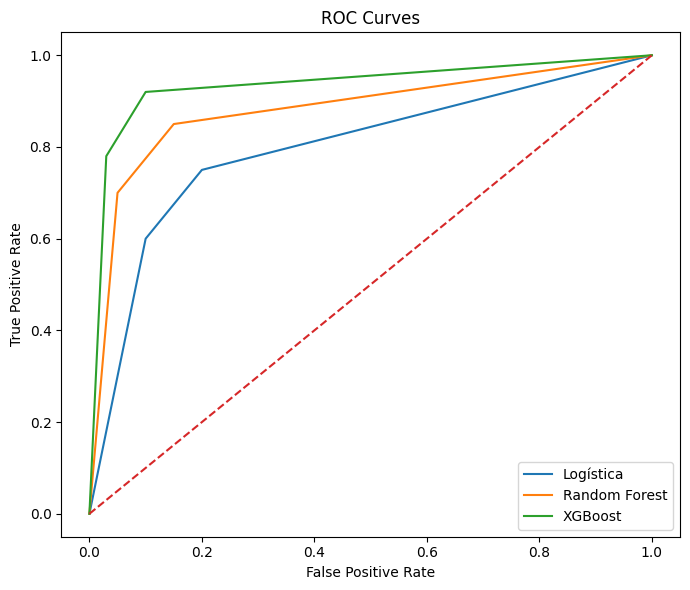

In [ ]:
#Grafica 14 (curvas ROC): curvas ROC para distintos modelos

fpr_log = [0.0, 0.1, 0.2, 1.0]
tpr_log = [0.0, 0.6, 0.75, 1.0]

fpr_rf = [0.0, 0.05, 0.15, 1.0]
tpr_rf = [0.0, 0.7, 0.85, 1.0]

fpr_xgb = [0.0, 0.03, 0.10, 1.0]
tpr_xgb = [0.0, 0.78, 0.92, 1.0]

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr_log, tpr_log, label="Logística")
ax.plot(fpr_rf, tpr_rf, label="Random Forest")
ax.plot(fpr_xgb, tpr_xgb, label="XGBoost")

ax.plot([0, 1], [0, 1], linestyle='--')

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves")
ax.legend()

plt.tight_layout()
plt.show()